# Nombre : Steven Moreta

In [5]:
tokens = list(range(1_000_000))

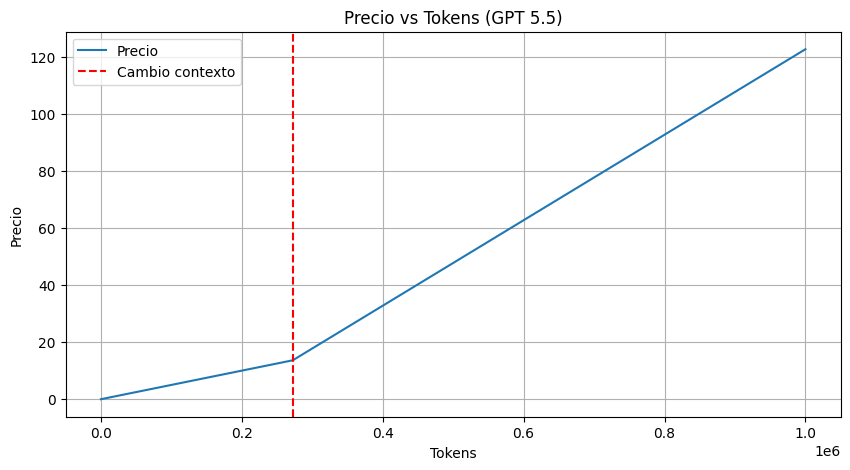


Intervalo inicial: [-5, 3]
Raíz aproximada encontrada: -1.000000

Intervalo inicial: [-4.7, 2.5]
El método fracasó después de 5 iteraciones

Intervalo inicial: [-4.5, 2.7]
El método fracasó después de 5 iteraciones

Intervalo inicial: [-3, -2]
No cumple f(a)*f(b) < 0 → No se puede aplicar bisección


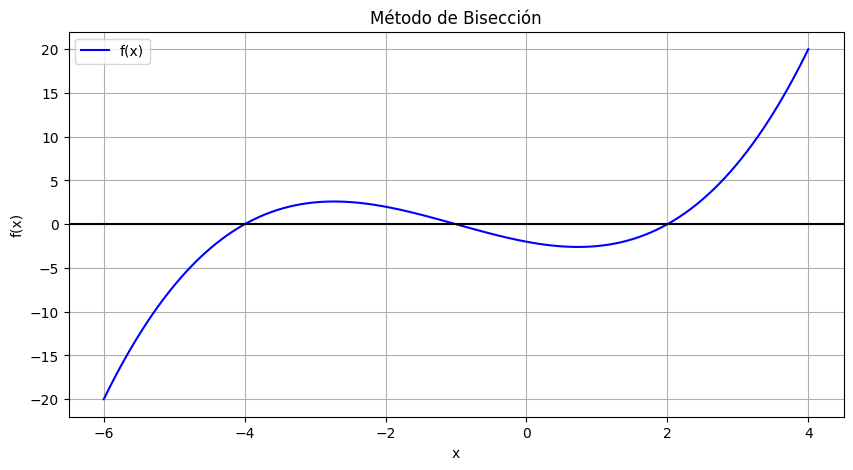

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


tokens = list(range(1_000_000))
precio = []

for t in tokens:
    if t <= 272_000:   # short context
        y = 0.00005 * t
    else:              # long context
        y_272k = 0.00005 * 272_000
        y = y_272k + 0.00015 * (t - 272_000)

    precio.append(y)

plt.figure(figsize=(10, 5))
plt.plot(tokens, precio, label="Precio")

# línea que separa short y long context
plt.axvline(x=272_000, linestyle='--', color='red', label='Cambio contexto')

plt.xlabel("Tokens")
plt.ylabel("Precio")
plt.title("Precio vs Tokens (GPT 5.5)")
plt.legend()
plt.grid(True)
plt.show()



def f(x):
    return (1/4)*(x**3 + 3*x**2 - 6*x - 8)


def biseccion(a, b, tol=1e-6, N0=5):
    i = 1
    FA = f(a)

    print(f"\nIntervalo inicial: [{a}, {b}]")

    # verificar condición del teorema
    if f(a) * f(b) > 0:
        print("No cumple f(a)*f(b) < 0 → No se puede aplicar bisección")
        return None

    while i <= N0:
        p = a + (b - a) / 2
        FP = f(p)

        if FP == 0 or (b - a)/2 < tol:
            print(f"Raíz aproximada encontrada: {p:.6f}")
            return p

        if FA * FP > 0:
            a = p
            FA = FP
        else:
            b = p

        i += 1

    print("El método fracasó después de 5 iteraciones")
    return None


# Rangos dados
rangos = [
    (-5, 3),
    (-4.7, 2.5),
    (-4.5, 2.7),
    (-3, -2)
]

for a, b in rangos:
    biseccion(a, b)




x = np.linspace(-6, 4, 1000)
y = f(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='f(x)', color='blue')

# eje X
plt.axhline(0, color='black')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Método de Bisección")
plt.legend()
plt.grid(True)

plt.show()


Intervalo inicial: [-5, 3]
Iter 1: p = -1.000000, f(p) = 0.000000
Raíz encontrada: -1.000000


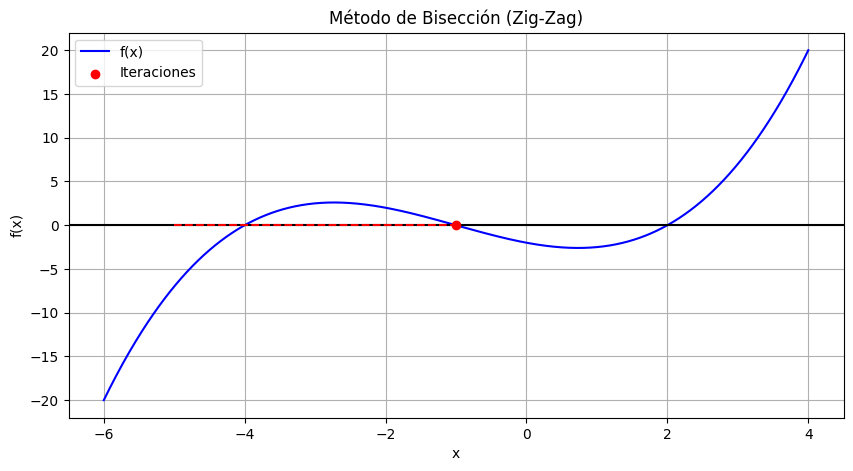

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Función del problema
def f(x):
    return (1/4)*(x**3 + 3*x**2 - 6*x - 8)

# Bisección guardando pasos para graficar
def biseccion_con_pasos(a, b, tol=1e-6, N0=5):
    pasos_x = []
    pasos_y = []

    FA = f(a)

    print(f"\nIntervalo inicial: [{a}, {b}]")

    if f(a) * f(b) > 0:
        print("No cumple f(a)*f(b) < 0")
        return None, pasos_x, pasos_y

    for i in range(1, N0 + 1):
        p = (a + b) / 2
        FP = f(p)

        # guardar paso (zig-zag)
        pasos_x.append(p)
        pasos_y.append(FP)

        print(f"Iter {i}: p = {p:.6f}, f(p) = {FP:.6f}")

        if FP == 0 or (b - a)/2 < tol:
            print(f"Raíz encontrada: {p:.6f}")
            return p, pasos_x, pasos_y

        if FA * FP > 0:
            a = p
            FA = FP
        else:
            b = p

    print("El método terminó en 5 iteraciones")
    return p, pasos_x, pasos_y



a, b = -5, 3
raiz, px, py = biseccion_con_pasos(a, b)


x = np.linspace(-6, 4, 1000)
y = f(x)

plt.figure(figsize=(10, 5))

# curva principal
plt.plot(x, y, label='f(x)', color='blue')

# eje X
plt.axhline(0, color='black')

# puntos del método
plt.scatter(px, py, color='red', zorder=3, label='Iteraciones')

# líneas zig-zag
for i in range(len(px)):
    plt.plot([px[i], px[i]], [0, py[i]], 'r--')  # vertical
    plt.plot([a, px[i]], [py[i], py[i]], 'r--')  # horizontal

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Método de Bisección (Zig-Zag)")
plt.legend()
plt.grid(True)

plt.show()
